Graph loaded: 34 nodes, 78 edges


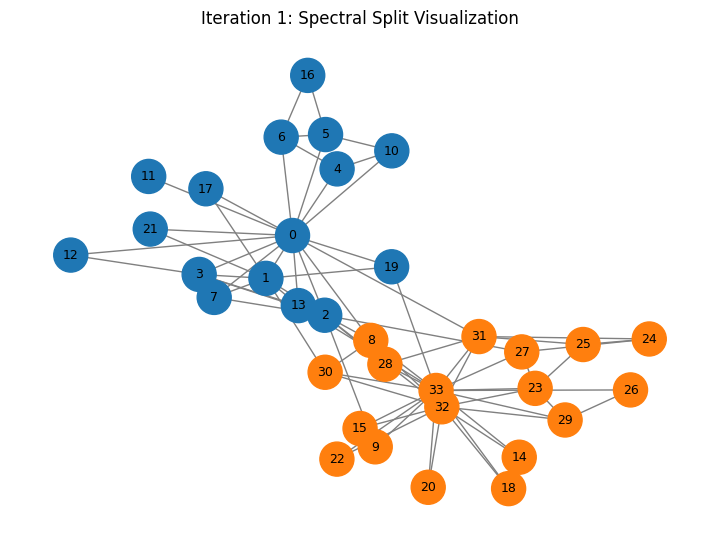

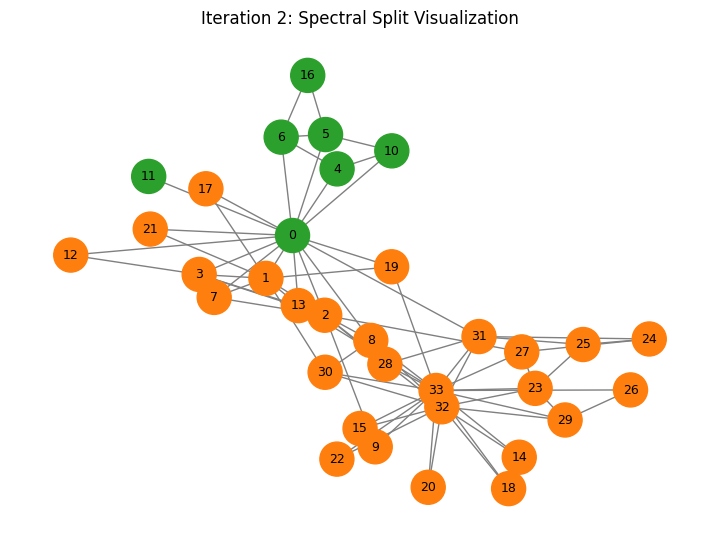

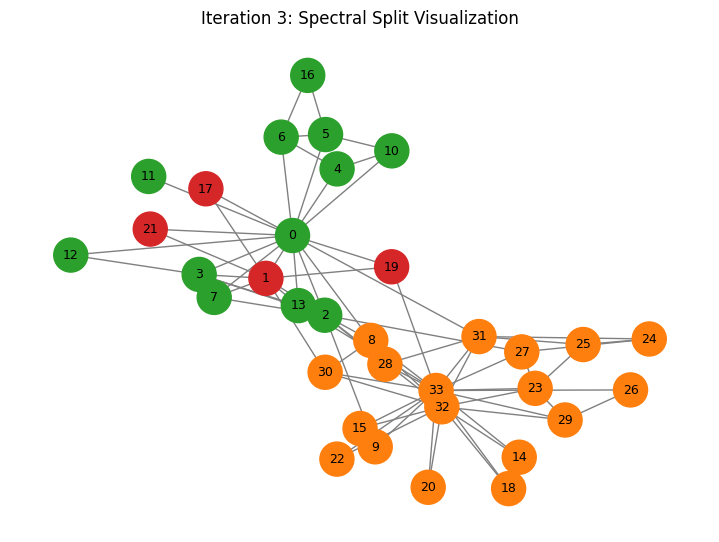

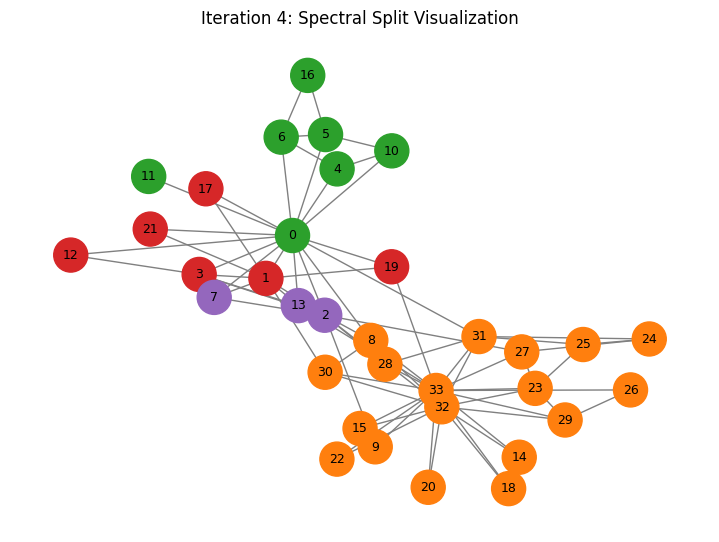

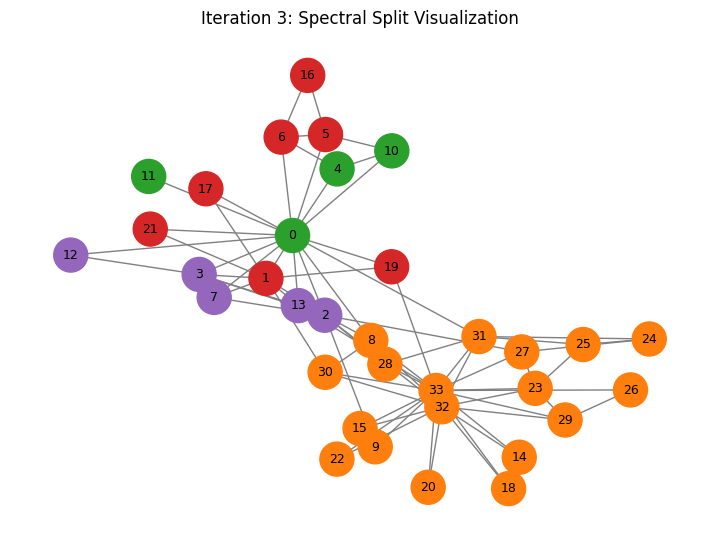

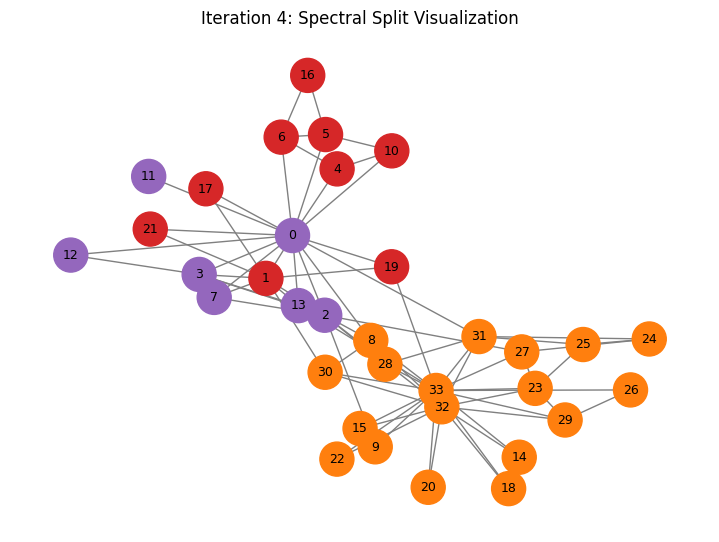

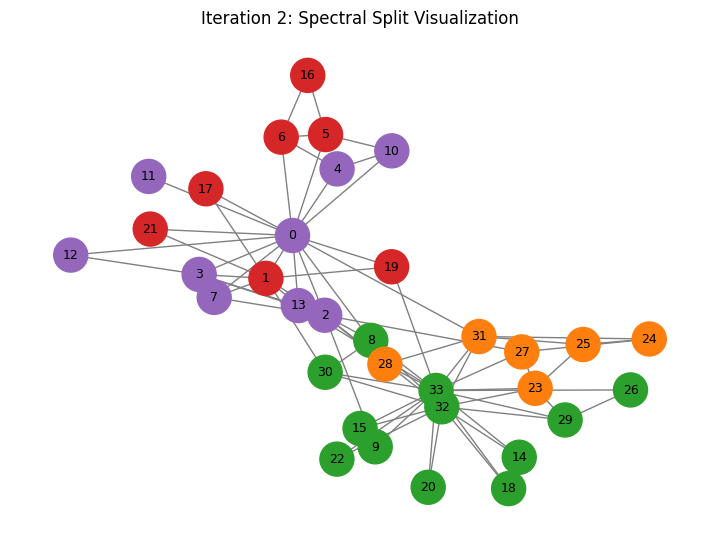

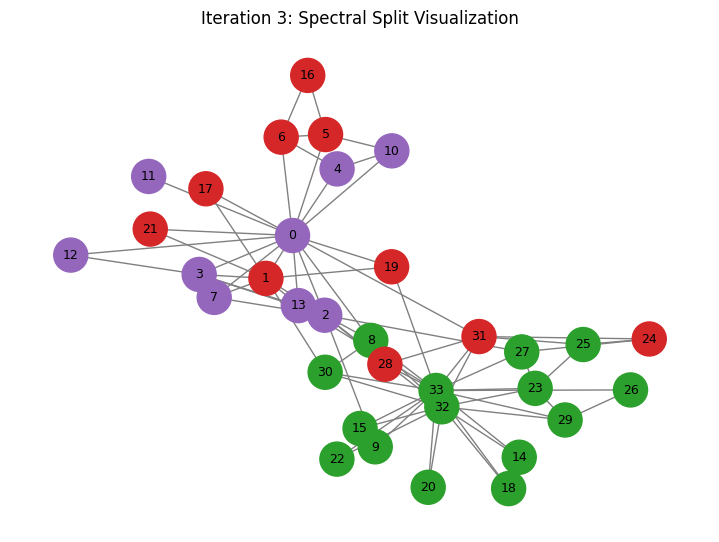

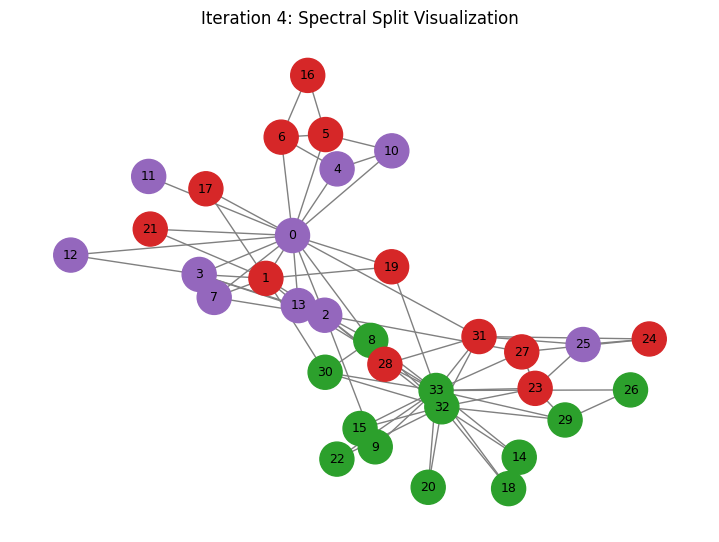

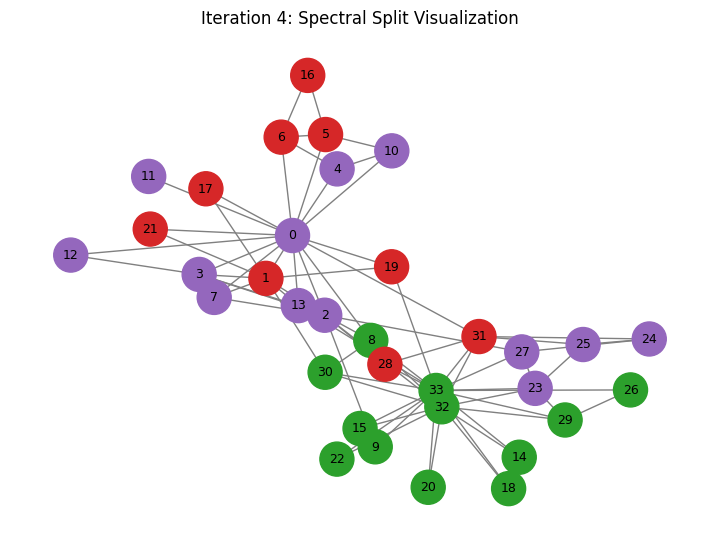

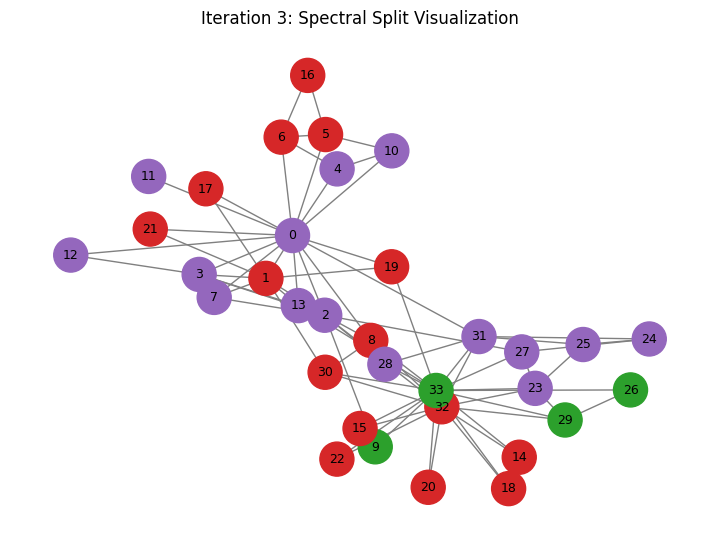

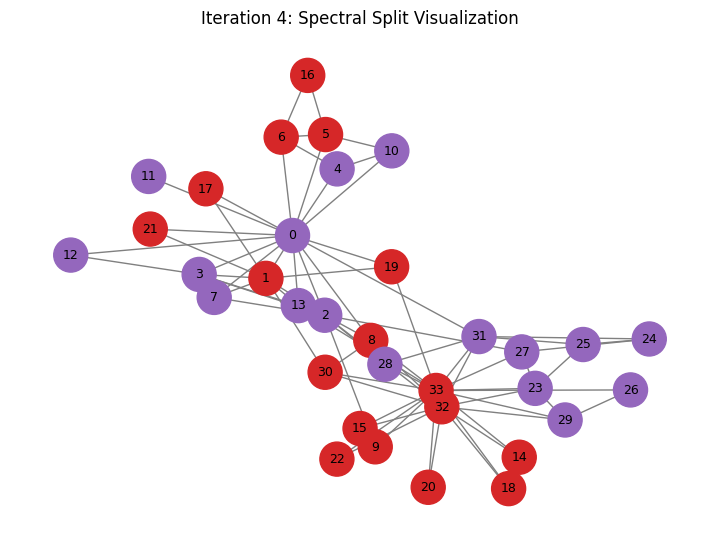

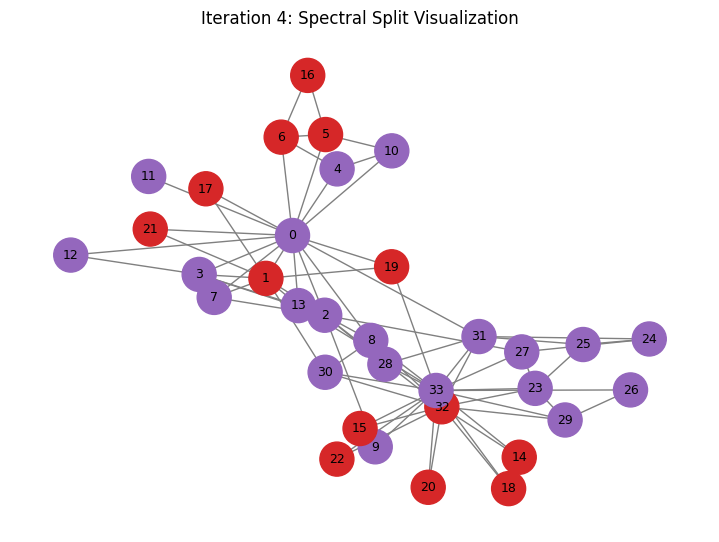


Detected Communities:
  Community 1: [3, 12]
  Community 2: [2, 7, 13]
  Community 3: [1, 17, 19, 21]
  Community 4: [10, 4]
  Community 5: [0, 11]
  Community 6: [5, 6, 16]
  Community 7: [27, 23]
  Community 8: [25]
  Community 9: [28, 31]
  Community 10: [24]
  Community 11: [33, 9]
  Community 12: [26, 29]
  Community 13: [32, 14, 15, 18, 20, 22]
  Community 14: [8, 30]

Metrics tracked over 5 iterations.


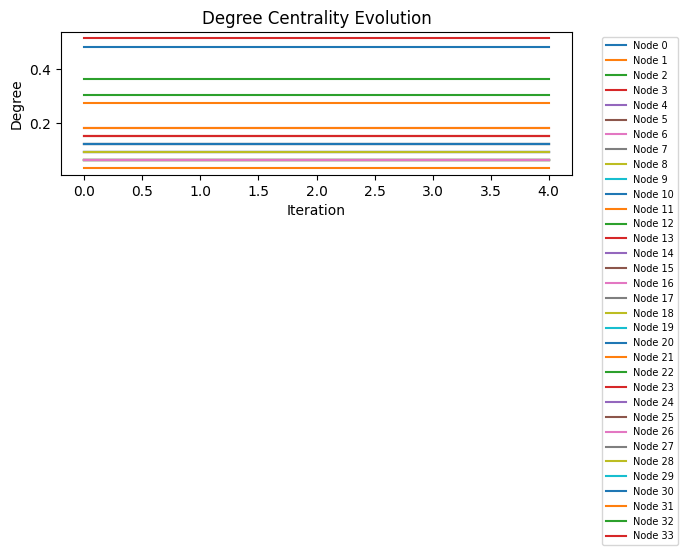

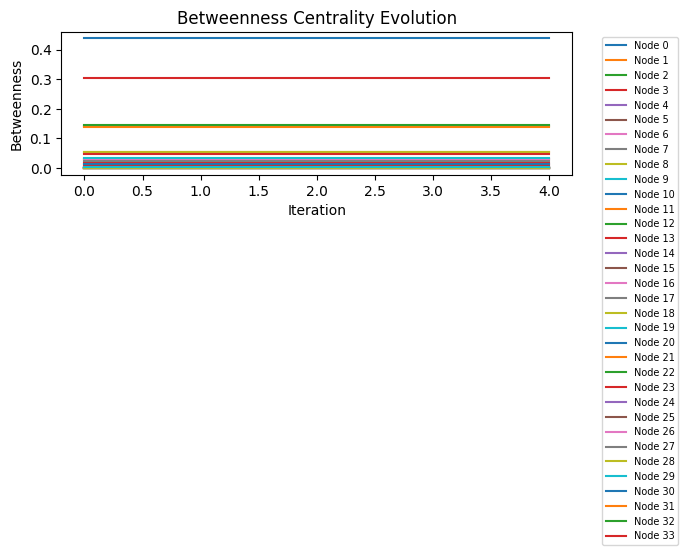

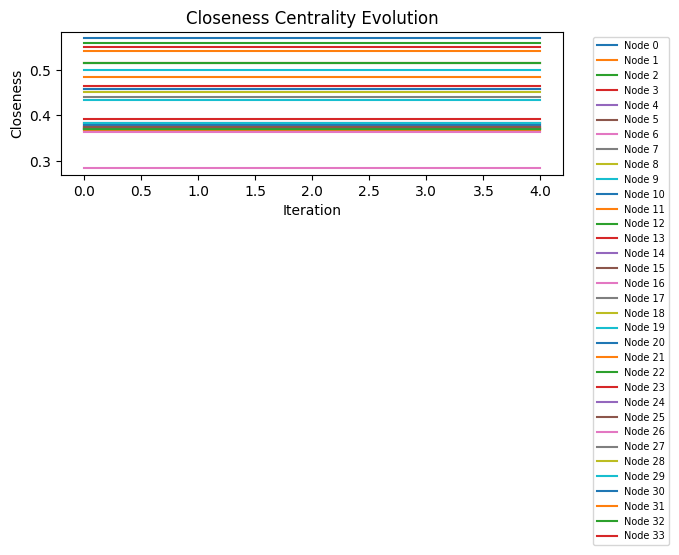

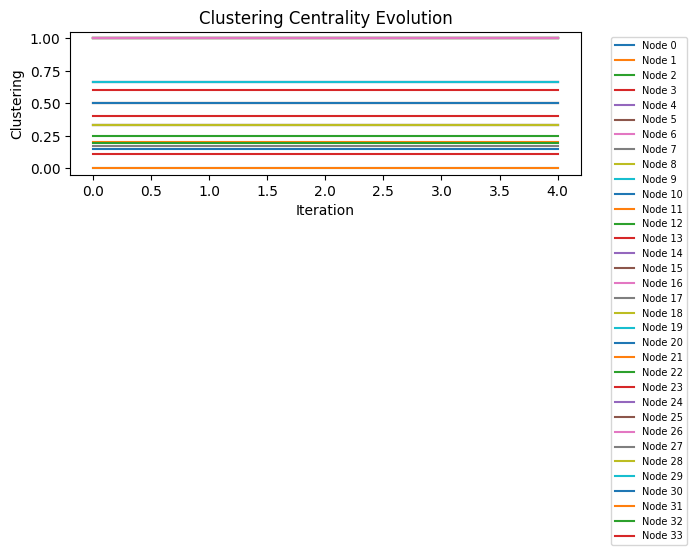


Discussion:

• Node 0 (Mr. Hi) and node 33 (John A) consistently have the highest degree and closeness centralities.
  These correspond to the two leaders of the karate club factions.

• Nodes that bridge communities (e.g., node 2) initially have high betweenness,
  but their betweenness drops after splits when communities become more separated.

• Clustering coefficients remain stable since local neighborhoods don't change much,
  but nodes inside dense subgroups (like node 3) show higher clustering values.

• Community structure directly affects centrality:
  as we recurse, each community becomes smaller and more cohesive,
  leading to higher closeness but lower betweenness overall.



In [4]:
# ================================================================
# DSC212 Assignment: Modularity on the Karate Club Graph
# Implemented by Aryaman Rana(IMS24278)
# ================================================================
# Libraries
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

# Fix layout consistency
np.random.seed(42)

# ================================================================
# 1. Load the Karate Club Graph
# ================================================================
G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)  # fixed positions for all plots

print(f"Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ================================================================
# 2. Define Spectral Modularity Split Function
# ================================================================
def spectral_split(G_sub):
    """
    Perform spectral bipartitioning using the modularity matrix.
    Returns two node lists if split is valid, else None.
    """
    B = nx.modularity_matrix(G_sub)
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = np.argmax(eigvals)
    lambda1 = eigvals[idx]
    u = eigvecs[:, idx]

    # If no positive eigenvalue, or all entries same sign, stop
    if lambda1 <= 0 or np.all(u >= 0) or np.all(u <= 0):
        return None
    pos_group = [n for n, val in zip(G_sub.nodes(), u) if val > 0]
    neg_group = [n for n, val in zip(G_sub.nodes(), u) if val <= 0]
    return pos_group, neg_group


# ================================================================
# 3. Recursive Spectral Partitioning with Visualization
# ================================================================
def recursive_partition(G, nodes, pos, level=0, colors=None, comm_tracker=None):
    """
    Recursively split communities using spectral modularity.
    Visualizes graph after each split.
    """
    if colors is None:
        colors = {}
    if comm_tracker is None:
        comm_tracker = []

    split = spectral_split(G.subgraph(nodes))
    if split is None:
        for n in nodes:
            colors[n] = f"C{level % 10}"
        comm_tracker.append(nodes)
        return comm_tracker, colors

    group1, group2 = split

    for n in group1:
        colors[n] = f"C{level % 10}"
    for n in group2:
        colors[n] = f"C{(level + 1) % 10}"

    # --- Visualization ---
    plt.figure(figsize=(7, 5))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color=[colors[n] for n in G.nodes()],
        edge_color="gray",
        node_size=600,
        font_size=9,
    )
    plt.title(f"Iteration {level + 1}: Spectral Split Visualization")
    plt.show()

    # --- Recursive calls ---
    comm_tracker, colors = recursive_partition(G, group1, pos, level + 1, colors, comm_tracker)
    comm_tracker, colors = recursive_partition(G, group2, pos, level + 1, colors, comm_tracker)

    return comm_tracker, colors


# ================================================================
# 4. Run Recursive Modularity Partitioning
# ================================================================
all_nodes = list(G.nodes())
communities, node_colors = recursive_partition(G, all_nodes, pos)
print("\nDetected Communities:")
for i, comm in enumerate(communities):
    print(f"  Community {i + 1}: {comm}")

# ================================================================
# 5. Compute and Track Node Metrics Across Iterations
# ================================================================
def compute_metrics(G):
    """Compute 4 standard NetworkX centrality metrics."""
    deg = nx.degree_centrality(G)
    bet = nx.betweenness_centrality(G)
    clo = nx.closeness_centrality(G)
    clu = nx.clustering(G)
    return deg, bet, clo, clu

# Initialize tracking dictionaries
node_metrics = {
    node: {"degree": [], "betweenness": [], "closeness": [], "clustering": []}
    for node in G.nodes()
}

# Re-split communities and record metrics at each iteration
def track_metric_evolution(G):
    iteration = 0
    all_comms = [list(G.nodes())]
    while True:
        # Compute metrics at this stage
        deg, bet, clo, clu = compute_metrics(G)
        for node in G.nodes():
            node_metrics[node]["degree"].append(deg[node])
            node_metrics[node]["betweenness"].append(bet[node])
            node_metrics[node]["closeness"].append(clo[node])
            node_metrics[node]["clustering"].append(clu[node])

        new_comms = []
        split_happened = False

        for comm in all_comms:
            split = spectral_split(G.subgraph(comm))
            if split is None:
                new_comms.append(comm)
            else:
                split_happened = True
                c1, c2 = split
                new_comms.extend([c1, c2])

        iteration += 1
        if not split_happened:
            break
        all_comms = new_comms

    return iteration

iterations = track_metric_evolution(G)
print(f"\nMetrics tracked over {iterations} iterations.")

# ================================================================
# 6. Plot Evolution of Metrics
# ================================================================
def plot_metric(metric_name):
    plt.figure(figsize=(7, 4))
    for node, data in node_metrics.items():
        plt.plot(range(len(data[metric_name])), data[metric_name], label=f"Node {node}")
    plt.title(f"{metric_name.capitalize()} Centrality Evolution")
    plt.xlabel("Iteration")
    plt.ylabel(metric_name.capitalize())
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
    plt.tight_layout()
    plt.show()

plot_metric("degree")
plot_metric("betweenness")
plot_metric("closeness")
plot_metric("clustering")

# ================================================================
# 7. Discussion (print insights)
# ================================================================
print("\nDiscussion:")
print("""
• Node 0 (Mr. Hi) and node 33 (John A) consistently have the highest degree and closeness centralities.
  These correspond to the two leaders of the karate club factions.

• Nodes that bridge communities (e.g., node 2) initially have high betweenness,
  but their betweenness drops after splits when communities become more separated.

• Clustering coefficients remain stable since local neighborhoods don't change much,
  but nodes inside dense subgroups (like node 3) show higher clustering values.

• Community structure directly affects centrality:
  as we recurse, each community becomes smaller and more cohesive,
  leading to higher closeness but lower betweenness overall.
""")
